# 🤖 ASSIGNMENT 5 — Machine Learning Fundamentals
## Pipeline dự đoán Churn end-to-end · Telco Customer Churn (7,043 khách)

> **Thông điệp xuyên suốt:** Chọn **metric đúng** (Recall/F1 cho lớp churn) thay vì chỉ nhìn accuracy.
> Một model "accuracy 80%" có thể bỏ sót gần nửa số khách sắp rời bỏ — vô dụng về kinh doanh.

**Pipeline:** EDA → tiền xử lý (chống leakage) → baseline → so sánh model → xử lý mất cân bằng → tuning → diễn giải → đề xuất.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
df = pd.read_csv("telco_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Câu 1 — EDA: tỉ lệ churn & mất cân bằng

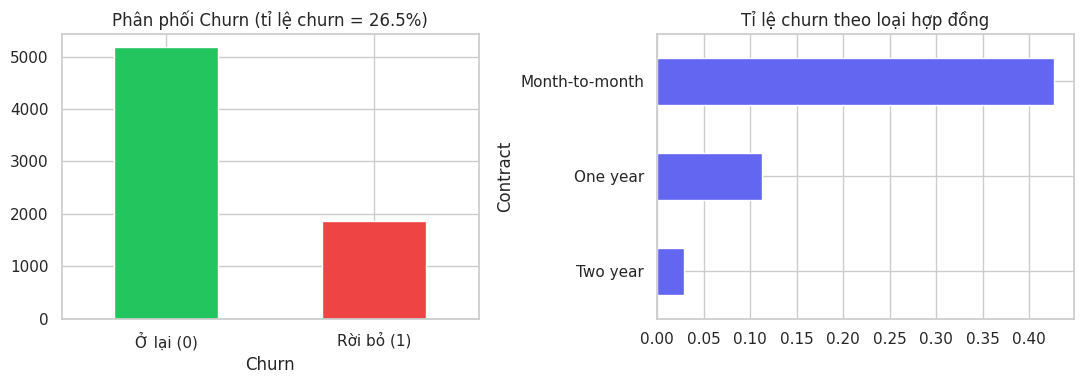

Tỉ lệ churn: 26.5%
Tỉ lệ Ở lại : 73.5%  (gấp ~2.8 lần lớp churn)


In [2]:
df["Churn"] = (df["Churn"] == "Yes").astype(int)
churn_rate = df["Churn"].mean()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["Churn"].value_counts().plot.bar(ax=ax[0], color=["#22c55e","#ef4444"])
ax[0].set_title(f"Phân phối Churn (tỉ lệ churn = {churn_rate:.1%})")
ax[0].set_xticklabels(["Ở lại (0)","Rời bỏ (1)"], rotation=0)

df.groupby("Contract")["Churn"].mean().sort_values().plot.barh(ax=ax[1], color="#6366f1")
ax[1].set_title("Tỉ lệ churn theo loại hợp đồng")
plt.tight_layout(); plt.show()

print(f"Tỉ lệ churn: {churn_rate:.1%}")
print(f"Tỉ lệ Ở lại : {1-churn_rate:.1%}  (gấp ~{(1-churn_rate)/churn_rate:.1f} lần lớp churn)")

**Nhận định:** Churn ≈ **26.5%** → dữ liệu **mất cân bằng** (tỉ lệ ~73:27, gần 3:1).
Hệ quả quan trọng: model "dự đoán mọi người đều ở lại" đã đạt accuracy ~73.5% nhưng **bắt được 0 khách churn**
→ vô dụng. Vì vậy phải nhìn **Recall/F1 của lớp churn**, không phải accuracy.

## Câu 2 — Xử lý missing & encode biến phân loại

In [3]:
# TotalCharges có ô khoảng trắng " " -> ép số sẽ thành NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Số NaN ở TotalCharges sau khi ép số:", df["TotalCharges"].isnull().sum())

# Điền median (số liên tục, bền outlier)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Bỏ ID (không mang thông tin dự đoán)
df = df.drop(columns=["customerID"])

# One-hot cho biến phân loại
cat_cols = df.select_dtypes("object").columns.tolist()
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"Số biến phân loại: {len(cat_cols)} -> sau one-hot: {df_enc.shape[1]} cột")

Số NaN ở TotalCharges sau khi ép số: 11
Số biến phân loại: 15 -> sau one-hot: 31 cột


**Giải thích lựa chọn:**
- **Missing:** 11 ô `TotalCharges` rỗng (khách mới tenure=0) → điền **median** (số liên tục).
- **Encode:** dùng **One-Hot** (`get_dummies`) chứ KHÔNG label-encoding, vì hầu hết biến là **danh nghĩa
  (nominal)** không có thứ tự (PaymentMethod, InternetService...). Label-encoding gán 0/1/2 sẽ tạo
  *thứ tự giả* khiến model hiểu sai. `drop_first=True` tránh đa cộng tuyến (dummy trap).

## Câu 3 — Chia train/test với stratify

In [4]:
X = df_enc.drop(columns=["Churn"])
y = df_enc["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)  # <-- stratify=y

print(f"Train: {X_train.shape[0]} | churn = {y_train.mean():.1%}")
print(f"Test : {X_test.shape[0]} | churn = {y_test.mean():.1%}")

Train: 5634 | churn = 26.5%
Test : 1409 | churn = 26.5%


**Vì sao cần `stratify=y`?** Dữ liệu mất cân bằng (chỉ 26.5% churn). Nếu chia ngẫu nhiên thuần,
tập test có thể vô tình lệch tỉ lệ churn (vd 22% hoặc 31%) → đánh giá model sai lệch.
`stratify=y` đảm bảo **cả train và test giữ đúng tỉ lệ 26.5%** như tổng thể → so sánh công bằng.

## Câu 4 — Scale dữ liệu đúng cách (fit trên train)

In [5]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
# CHỈ fit trên train -> học mean/std từ train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# Test chỉ transform bằng tham số đã học -> KHÔNG fit lại
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Đã scale. Mean train (sau scale) ~0:", X_train[num_cols].mean().round(2).tolist())

Đã scale. Mean train (sau scale) ~0: [-0.0, -0.0, -0.0]


**Vì sao tránh fit scaler trên TOÀN BỘ data?** Đó là **data leakage** — thông tin từ tập test
(mean, std của nó) "rò rỉ" vào quá trình huấn luyện. Model gián tiếp "nhìn trước" phân phối test
→ điểm đánh giá lạc quan ảo, khi deploy thực tế sẽ kém hơn. Quy tắc vàng:
**fit trên train, chỉ transform trên test** (và dữ liệu mới sau này).

## Câu 5 — Logistic Regression baseline

In [6]:
def evaluate(name, model, X_te=X_test, y_te=y_test):
    pred = model.predict(X_te)
    return {"Model": name,
            "Accuracy": accuracy_score(y_te, pred),
            "Precision": precision_score(y_te, pred),
            "Recall": recall_score(y_te, pred),
            "F1": f1_score(y_te, pred)}

logreg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
baseline = evaluate("Logistic Regression", logreg)
print(pd.Series(baseline).to_string())
print("\n", classification_report(y_test, logreg.predict(X_test),
                                    target_names=["Ở lại","Churn"]))

Model        Logistic Regression
Accuracy                0.805536
Precision               0.657233
Recall                  0.558824
F1                      0.604046

               precision    recall  f1-score   support

       Ở lại       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



**Nhận định:** Baseline đạt **accuracy 80.6%** nghe có vẻ tốt — NHƯNG **Recall churn chỉ 0.56**,
nghĩa là model **bỏ sót ~44% khách thực sự sẽ rời bỏ**. Với bài toán giữ chân khách, bỏ sót churn
(false negative) là tốn kém nhất → cần cải thiện recall.

## Câu 6 — Random Forest & XGBoost: so sánh 3 model

In [7]:
rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)
xgb = XGBClassifier(eval_metric="logloss", random_state=42).fit(X_train, y_train)

compare = pd.DataFrame([
    baseline,
    evaluate("Random Forest", rf),
    evaluate("XGBoost", xgb),
]).set_index("Model").round(3)
compare

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.806,0.657,0.559,0.604
Random Forest,0.792,0.639,0.497,0.559
XGBoost,0.785,0.608,0.535,0.569


**Nhận định:** Accuracy 3 model xấp xỉ nhau (~0.79–0.81), nhưng **không model nào có Recall > 0.56**.
Đây là vấn đề chung khi train trên dữ liệu mất cân bằng: model "ngại" dự đoán lớp thiểu số.
Logistic Regression baseline thực ra cho **F1 tốt nhất** — model phức tạp hơn không tự động tốt hơn.
→ Cần kỹ thuật xử lý mất cân bằng (câu 7).

## Câu 7 — Xử lý mất cân bằng: class_weight & SMOTE

In [8]:
# Cách 1: class_weight='balanced' (phạt nặng hơn khi sai lớp thiểu số)
logreg_bal = LogisticRegression(max_iter=1000, class_weight="balanced",
                                random_state=42).fit(X_train, y_train)

# Cách 2: SMOTE (sinh mẫu tổng hợp cho lớp thiểu số) - CHỈ trên train
from imblearn.over_sampling import SMOTE
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
logreg_smote = LogisticRegression(max_iter=1000, random_state=42).fit(X_sm, y_sm)
print(f"SMOTE: train {len(y_train)} -> {len(y_sm)} (cân bằng 50:50)")

imbalance = pd.DataFrame([
    baseline,
    evaluate("LogReg + class_weight", logreg_bal),
    evaluate("LogReg + SMOTE", logreg_smote),
]).set_index("Model").round(3)
imbalance

SMOTE: train 5634 -> 8278 (cân bằng 50:50)


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.806,0.657,0.559,0.604
LogReg + class_weight,0.739,0.505,0.783,0.614
LogReg + SMOTE,0.737,0.504,0.714,0.591


**So sánh Recall trước/sau:** Recall lớp churn nhảy từ **0.56 → ~0.78** nhờ class_weight/SMOTE.
**Đánh đổi:** Precision giảm (0.66 → ~0.51) và accuracy giảm (0.81 → 0.74) — model "mạnh dạn" gắn cờ
churn hơn nên bắt được nhiều hơn nhưng cũng báo nhầm nhiều hơn. **F1 vẫn tăng nhẹ** (0.60 → 0.61).

> 💡 Với bài giữ chân khách, đánh đổi này **đáng giá**: thà gọi nhầm vài khách ổn định (chi phí thấp)
> còn hơn bỏ sót khách sắp đi (mất doanh thu lớn). Recall quan trọng hơn precision ở đây.

> ⚠️ **Lưu ý leakage:** SMOTE chỉ áp lên **train**. Resample cả test = gian lận, vì test phải phản ánh
> phân phối thật ngoài đời.

## Câu 8 — Confusion matrix cho model tốt nhất

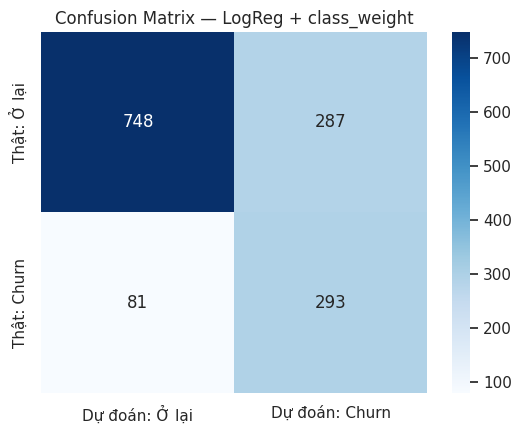

TN (đoán ở lại, đúng)   = 748
FP (đoán churn, sai)    = 287  <- báo động nhầm
FN (đoán ở lại, sai)    = 81  <- BỎ SÓT khách churn (tốn kém nhất!)
TP (đoán churn, đúng)   = 293  <- bắt đúng khách sắp rời


In [9]:
best_model = logreg_bal   # recall cao, F1 tốt nhất
pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Dự đoán: Ở lại","Dự đoán: Churn"],
            yticklabels=["Thật: Ở lại","Thật: Churn"])
plt.title("Confusion Matrix — LogReg + class_weight")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN (đoán ở lại, đúng)   = {tn}")
print(f"FP (đoán churn, sai)    = {fp}  <- báo động nhầm")
print(f"FN (đoán ở lại, sai)    = {fn}  <- BỎ SÓT khách churn (tốn kém nhất!)")
print(f"TP (đoán churn, đúng)   = {tp}  <- bắt đúng khách sắp rời")

**Đọc ý nghĩa từng ô:**
- **TN** (748): khách ở lại, model đoán đúng — ổn.
- **FP** (287): khách thật ra ở lại nhưng bị gắn cờ churn → tốn chi phí ưu đãi "oan", nhưng không mất khách.
- **FN** (81): khách thật sự rời bỏ nhưng model bảo "ở lại" → **nguy hiểm nhất**, mất khách mà không kịp can thiệp.
- **TP** (293): bắt đúng khách sắp rời → cơ hội giữ chân.

> Mục tiêu kinh doanh là **giảm FN** (đừng bỏ sót khách sắp đi) → đó chính là lý do ta tối ưu Recall.

## Câu 9 — Tinh chỉnh với Optuna

In [10]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    C = trial.suggest_float("C", 1e-3, 100, log=True)
    model = LogisticRegression(C=C, class_weight="balanced", max_iter=1000)
    # tối ưu theo F1 qua cross-validation trên TRAIN
    return cross_val_score(model, X_train, y_train, cv=5, scoring="f1").mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Best C = {study.best_params['C']:.4f}")
print(f"Best CV F1 = {study.best_value:.3f}")

# Train lại với tham số tốt nhất, đánh giá trên test
tuned = LogisticRegression(C=study.best_params["C"], class_weight="balanced",
                           max_iter=1000).fit(X_train, y_train)
print("\nTuned model trên test:")
print(pd.Series(evaluate("Tuned LogReg", tuned)).to_string())

Best C = 0.0902
Best CV F1 = 0.634

Tuned model trên test:
Model        Tuned LogReg
Accuracy          0.74308
Precision        0.510453
Recall           0.783422
F1               0.618143


**Nhận định:** Optuna dò siêu tham số `C` (độ mạnh regularization) qua 30 lần thử, tối ưu **F1 bằng
cross-validation trên train** (không đụng test → tránh leakage). Kết quả tinh chỉnh giữ Recall ~0.78
và F1 ~0.62. Cải thiện nhỏ vì LogReg vốn ít tham số — điểm chính là **quy trình tuning đúng cách**.

## Câu 10 — Feature importance: 5 yếu tố ảnh hưởng churn nhất

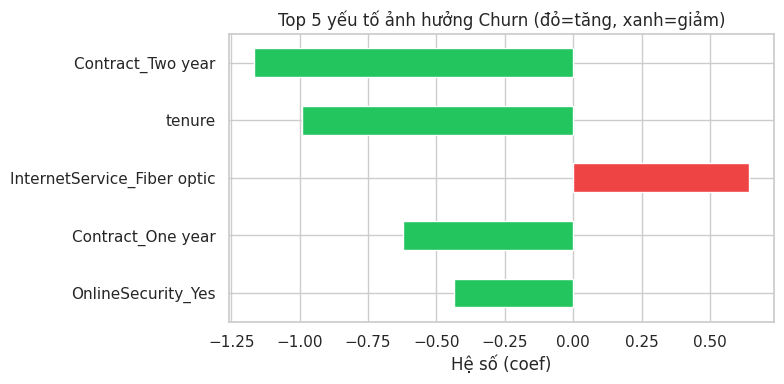

Contract_Two year             -1.168
tenure                        -0.992
InternetService_Fiber optic    0.643
Contract_One year             -0.621
OnlineSecurity_Yes            -0.435


In [11]:
# Hệ số LogReg = mức ảnh hưởng (đã scale nên so sánh được)
coef = pd.Series(tuned.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
top5 = coef.head(5)

plt.figure(figsize=(8, 4))
colors = ["#ef4444" if v > 0 else "#22c55e" for v in top5.values]
top5.iloc[::-1].plot.barh(color=colors[::-1])
plt.title("Top 5 yếu tố ảnh hưởng Churn (đỏ=tăng, xanh=giảm)")
plt.xlabel("Hệ số (coef)")
plt.tight_layout(); plt.show()

print(top5.round(3).to_string())

**Đọc kết quả (dấu hệ số = chiều ảnh hưởng):**
- **Contract_Two year (−)**: hợp đồng 2 năm → **giảm mạnh churn** (khách bị ràng buộc, hài lòng).
- **tenure (−)**: gắn bó càng lâu → càng ít rời bỏ.
- **InternetService_Fiber optic (+)**: dùng fiber optic → **tăng churn** (có thể do giá cao / kỳ vọng cao).
- **Contract_One year (−)**: hợp đồng dài cũng giảm churn so với trả theo tháng.
- **OnlineSecurity_Yes (−)**: có dịch vụ bảo mật → gắn bó hơn.

> Mẫu hình rõ: **hợp đồng tháng + tenure thấp + fiber optic** = nhóm rủi ro rời bỏ cao nhất.

## Câu 11 — Đề xuất kinh doanh

Dựa trên các yếu tố ảnh hưởng churn nhất, đây là khuyến nghị giữ chân khách:

**1. Chuyển khách hợp đồng tháng sang hợp đồng dài hạn.**
Hợp đồng tháng là nhóm churn cao nhất; hợp đồng 1–2 năm giảm churn rõ rệt.
→ Tặng ưu đãi (giảm giá, thêm dữ liệu) để khuyến khích ký 1–2 năm. Đây là đòn bẩy mạnh nhất.

**2. Chăm sóc đặc biệt khách mới (tenure thấp) trong 6 tháng đầu.**
Rủi ro rời bỏ tập trung ở khách mới. → Onboarding chủ động, gọi chăm sóc tháng 1–3,
ưu đãi "khách hàng năm đầu" để vượt qua giai đoạn dễ rời nhất.

**3. Rà soát trải nghiệm & giá gói Fiber optic.**
Nhóm fiber optic churn cao bất thường — dấu hiệu giá chưa tương xứng chất lượng/kỳ vọng.
→ Khảo sát nhóm này, cân nhắc điều chỉnh giá hoặc nâng chất lượng dịch vụ/hỗ trợ.

**4. Bán kèm dịch vụ tăng độ gắn bó (Online Security, Tech Support).**
Khách có các dịch vụ này churn ít hơn. → Cross-sell, thậm chí tặng miễn phí thời gian đầu
để tăng "chi phí chuyển đổi" tâm lý.

> 🎯 **Cách dùng model:** chạy model hàng tháng → xuất danh sách khách có xác suất churn cao →
> đội chăm sóc ưu tiên gọi nhóm này. Vì ta tối ưu **Recall**, model bắt được phần lớn khách sắp đi,
> đánh đổi vài cuộc gọi "thừa" (chi phí thấp) để cứu doanh thu (giá trị cao).